# Wikidata genre tree — exploration

Exploratory notebook over the Bronze `wikidata_genre_tree.parquet` output (see [`../SCHEMA.md`](../SCHEMA.md#bronze)). Reads the local Parquet file only — no live SPARQL calls.

**Prerequisite:** run the ingest step first so the Parquet file exists:

```bash
uv run --package wikidata python -m wikidata.ingest
```

In [8]:
import os
from pathlib import Path

import networkx as nx
import polars as pl
from dotenv import load_dotenv

PIPELINE_ROOT = Path("..").resolve()
load_dotenv(PIPELINE_ROOT / ".env")

bronze_output_dir = Path(os.environ["BRONZE_OUTPUT_DIR"])
if not bronze_output_dir.is_absolute():
    bronze_output_dir = PIPELINE_ROOT / bronze_output_dir

bronze_path = bronze_output_dir / "wikidata_genre_tree.parquet"
df = pl.read_parquet(bronze_path)
df.shape

(9722, 5)

## Tabular exploration

In [2]:
df.head(10)

item_id,item_label,parent_id,parent_label,relation_type
str,str,str,str,str
"""Q178145""","""gothic metal""","""Q12326776""","""metal music""","""P279"""
"""Q180268""","""gospel music""","""Q6452410""","""Christian music""","""P279"""
"""Q180853""","""pavane""","""Q118738876""","""classical dance music""","""P279"""
"""Q181010""","""hard bop""","""Q105513""","""bebop""","""P279"""
"""Q181014""","""fugue""","""Q9730""","""classical music""","""P279"""
"""Q181014""","""fugue""","""Q186393""","""counterpoint""","""P279"""
"""Q181014""","""fugue""","""Q207628""","""composed musical work""","""P279"""
"""Q181861""","""noise rock""","""Q11399""","""rock music""","""P279"""
"""Q181861""","""noise rock""","""Q726239""","""noise music""","""P279"""


In [3]:
df.group_by("relation_type").len().sort("len", descending=True)

relation_type,len
str,u32
"""P279""",8984
null,488
"""P361""",250


In [4]:
roots = df.filter(pl.col("parent_id").is_null())
print(f"{roots.height} root items")
roots.select("item_id", "item_label").head(10)

488 root items


item_id,item_label
str,str
"""Q11352348""","""Ichichubushi"""
"""Q11375663""","""Kyoto kei music"""
"""Q11385637""","""Zokugaku"""
"""Q11512436""","""Minshingaku"""
"""Q11563285""","""Shonan Sound"""
"""Q11787400""","""vocal-instrumental music"""
"""Q11903204""","""Zouk chouv"""
"""Q11912270""","""caramelles"""
"""Q11955376""","""Xeremiers"""


In [5]:
multi_parent = (
    df.filter(pl.col("parent_id").is_not_null())
    .group_by("item_id", "item_label")
    .agg(pl.col("parent_id").n_unique().alias("n_parents"))
    .filter(pl.col("n_parents") > 1)
    .sort("n_parents", descending=True)
)
print(f"{multi_parent.height} items with more than one parent")
multi_parent.head(10)

2839 items with more than one parent


item_id,item_label,n_parents
str,str,u32
"""Q63203971""","""religious hymn""",9
"""Q135637""","""chiptune""",7
"""Q856713""","""Christian hymn""",7
"""Q2035976""","""Nintendocore""",6
"""Q2746831""","""quiet storm""",6
"""Q12228855""","""al-ayyalah""",6
"""Q1123037""","""nursery rhyme""",5
"""Q1202208""","""joropo""",5
"""Q16937368""","""koliadka""",5


## Graph visualization

The full tree (~9,700 edges) is too dense to render usefully in one plot, so build the full graph for structural stats, then plot just the neighborhood around a single genre.

In [6]:
G = nx.DiGraph()
for row in df.iter_rows(named=True):
    G.add_node(row["item_id"], label=row["item_label"])
    if row["parent_id"] is not None:
        G.add_edge(row["item_id"], row["parent_id"], relation=row["relation_type"])

print(f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"{nx.number_weakly_connected_components(G)} weakly connected components")

6881 nodes, 9220 edges
527 weakly connected components


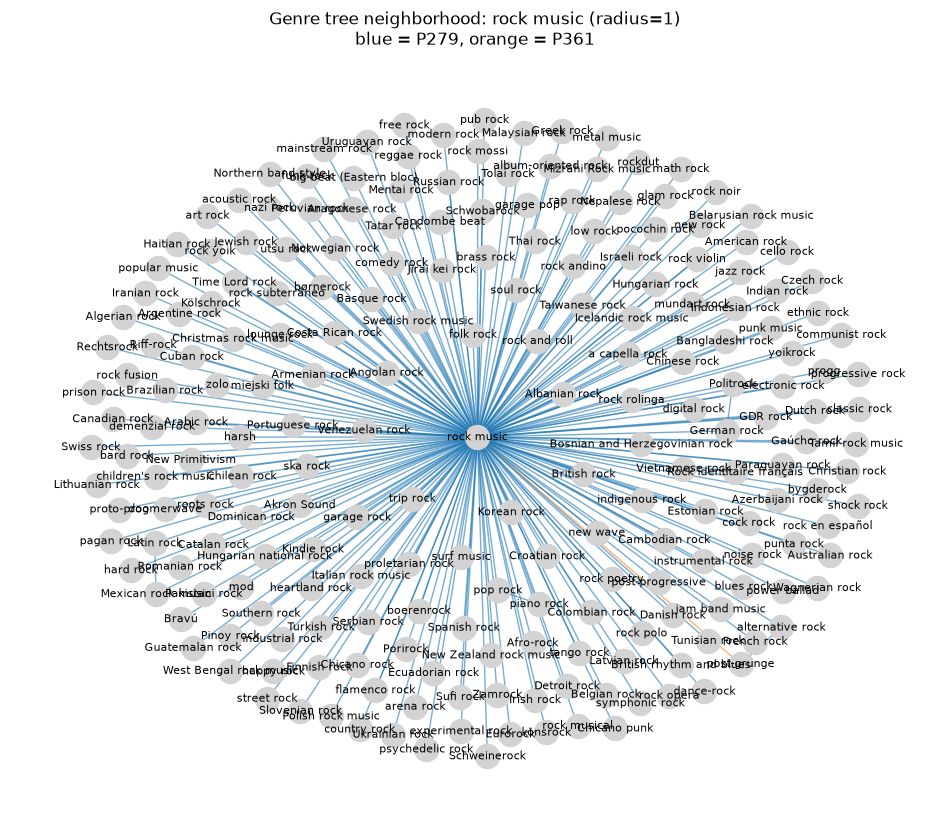

In [7]:
import matplotlib.pyplot as plt

ITEM_ID = "Q11399"  # rock music — change this to explore a different genre
RADIUS = 1  # networkx's spring_layout needs scipy for subgraphs of 500+ nodes; radius=1 stays well under that

undirected = G.to_undirected()
subgraph = nx.ego_graph(undirected, ITEM_ID, radius=RADIUS)


def edge_relation(u: str, v: str) -> str | None:
    return G.get_edge_data(u, v, {}).get("relation") or G.get_edge_data(v, u, {}).get("relation")


edge_colors = ["tab:blue" if edge_relation(u, v) == "P279" else "tab:orange" for u, v in subgraph.edges()]
labels = {n: G.nodes[n].get("label", n) for n in subgraph.nodes()}

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(subgraph, seed=42)
nx.draw_networkx_nodes(subgraph, pos, node_size=300, node_color="lightgray")
nx.draw_networkx_edges(subgraph, pos, edge_color=edge_colors, alpha=0.6)
nx.draw_networkx_labels(subgraph, pos, labels=labels, font_size=8)
plt.title(f"Genre tree neighborhood: {labels[ITEM_ID]} (radius={RADIUS})\nblue = P279, orange = P361")
plt.axis("off")
plt.show()